In [1]:
list.of.packages <- c("tidyverse","ggfixest","stargazer","data.table","broom")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Le chargement a nécessité le package : fixest


Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 



Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter,

In [2]:
T_bins_labels <- c("<=17°C","17,21]","21,23]","23,25]","25,27]","27,29]","29,31]","31,33]",">33°C")
T_bins_labels_pretty <- c("≤17°C", "(17,21]", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")

bin_ref_T <-"17,21]"

# Children continuous controls

In [3]:
df_children <- fread("./2_Regression_datasets/output/df_reg_children.csv")
sprintf("%i rows x %i columns", nrow(df_children), ncol(df_children))
head(df_children,2)

[1] "281812 rows x 321 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Mother_id,Child_id,Resp_nb,Interview_month,Interview_year,Measured_date_CDC,Measured_date,Measured_day,Measured_month,Measured_year,Birth_month,Birth_year,Child_female,Child_birth_order,Child_alive_age_month,Child_hemo_level_alti,Child_weight_for_height_zscore,Child_diarrhea,Child_fever,Child_cough,Child_still_breastfeeding,Child_given_plain_water,Child_given_juice,Child_given_milk,Child_given_baby_formula,Child_given_fortified_baby_food,Child_given_soup,Child_given_other_liquid,Child_given_chicken_duck_birds,Child_given_bread_noodles_grains,Child_given_potatoes_cassava_tubers,Child_given_eggs,Child_given_pumkins_carrots_squash,Child_given_green_vegetables,Child_given_mangoes_papaya_vitaminAfruits,Child_given_other_fruits,Child_given_liver_heart_organs,Child_given_fish_sellfish,Child_given_beans_peas_lentils_nuts,Child_given_cheese_yogurt_milk_products,Child_given_other_solid_semisolid_food,Child_given_other_meat,Child_given_yogurt,Child_iron_supplem_7d,Mother_no_educ,Mother_prim_educ,Mother_second_educ,Mother_higher_educ,Mother_hindu,Mother_muslim,Mother_not_hindu_nor_muslim,Mother_ethni_SC,Mother_ethni_ST,Mother_ethni_OBC,Mother_ethni_other,Mother_height,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,Interview_cdc,Wasted,Age_rounded,Children_anemia,Child_severe_anemia,Child_moderate_anemia,Child_mild_anemia,Child_no_anemia,Season,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_

In [4]:
df_reg_children <- df_children %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels))

In [5]:
reg_children_birtho <- feols(Child_birth_order ~ i(T_i30_bin,ref=bin_ref_T) 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                               vcov = ~District_ID,
                               df_reg_children)

NOTE: 36/7 fixed-effect singletons were removed (36 observations).



In [6]:
reg_children_age <- feols(Child_alive_age_month ~ i(T_i30_bin,ref=bin_ref_T) 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                               vcov = ~District_ID,
                               df_reg_children)

NOTE: 36/7 fixed-effect singletons were removed (36 observations).



# Women continuous controls

In [7]:
df_women <- fread("./2_Regression_datasets/output/df_reg_women.csv")
sprintf("%i rows x %i columns", nrow(df_women), ncol(df_women))
head(df_women,2)

[1] "973462 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Women_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Currently_pregnant,Blood_hemo_level_alti,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Body_mass_index,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Women_anemia,Women_severe_anemia,Women_moderate_anemia,Women_mild_anemia,Women_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T

In [8]:
df_reg_women <- df_women %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels))

In [9]:
reg_women_age <- feols(Current_age ~ i(T_i30_bin,ref=bin_ref_T) 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                    df_reg_women)

NOTE: 14/0 fixed-effect singletons were removed (14 observations).



In [10]:
reg_women_educ <- feols(N_year_educ ~ i(T_i30_bin,ref=bin_ref_T) 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                    df_reg_women)

NOTE: 14/0 fixed-effect singletons were removed (14 observations).



In [11]:
rm(df_women,df_reg_women)

# Men continuous controls

In [12]:
df_men <- fread("./2_Regression_datasets/output/df_reg_men.csv")
sprintf("%i rows x %i columns", nrow(df_men), ncol(df_men))
head(df_men,2)

[1] "150101 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Men_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Profession,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Blood_hemo_level_alti,Body_mass_index,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Men_anemia,Men_severe_anemia,Men_moderate_anemia,Men_mild_anemia,Men_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T_MaxBin_27_29_Ndays_

In [13]:
df_reg_men <- df_men %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels))

In [14]:
reg_men_age <- feols(Current_age ~ i(T_i30_bin,ref=bin_ref_T) 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                    df_reg_men)

NOTE: 16/0 fixed-effect singletons were removed (16 observations).



In [15]:
reg_men_educ <- feols(N_year_educ ~ i(T_i30_bin,ref=bin_ref_T) 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                           vcov = ~District_ID,
                    df_reg_men)

NOTE: 16/0 fixed-effect singletons were removed (16 observations).



# Extract coefs for plotting

In [16]:
extract_coefs <- function(reg,item,gender){
        coef_tab_estim <- as.data.frame(rbind(tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::<=17°C")%>% 
                                                 mutate(item = item, 
                                                        specifi= gender,
                                                        label = "≤17°C"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::21,23]")%>% 
                                                 mutate(item = item, 
                                                        specifi= gender,
                                                        label = "(21,23]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::23,25]")%>% 
                                                 mutate(item = item, 
                                                        specifi= gender,
                                                        label = "(23,25]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::25,27]")%>% 
                                                 mutate(item = item, 
                                                        specifi= gender,
                                                        label = "(25,27]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::27,29]")%>% 
                                                 mutate(item = item, 
                                                        specifi= gender,
                                                        label = "(27,29]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::29,31]")%>% 
                                                 mutate(item = item, 
                                                        specifi= gender,
                                                        label = "(29,31]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::31,33]")%>% 
                                                 mutate(item = item, 
                                                        specifi= gender,
                                                        label = "(31,33]"),
                                              tidy(reg,conf.int=TRUE)%>%
                                                 filter(term=="T_i30_bin::>33°C")%>% 
                                                 mutate(item = item, 
                                                        specifi= gender,
                                                        label = ">33°C")
                                             ))%>%
                                
                            add_row(term=NA,estimate=0,std.error=NA,statistic=NA,p.value=NA,
                                    conf.low=0,conf.high=0,item=item,specifi=gender,label="(17,21]")
}

In [17]:
coefs_item_adults <- function(label_item,reg_women,reg_men){
         rbind(extract_coefs(reg_women,label_item,"Women"),
               extract_coefs(reg_men,label_item,"Men"))%>%
               mutate(label=factor(label,levels=T_bins_labels_pretty),
                      specifi=factor(specifi,levels=c("Women","Men")))
}

In [18]:
coefs_item_children <- function(label_item,reg_children){
         rbind(extract_coefs(reg_children,label_item,"Children"))%>%
               mutate(label=factor(label,levels=T_bins_labels_pretty))
}

In [19]:
coefs_age_adults <- coefs_item_adults("Age (years)",reg_women_age,reg_men_age)
coefs_educ_adults <- coefs_item_adults("Education (years)",reg_women_educ,reg_men_educ)
coefs_birthord_children <- coefs_item_children("Birth order",reg_children_birtho)
coefs_age_children <- coefs_item_children("Age (months)",reg_children_age)

# Plot

In [20]:
all_coefs_years <- rbind(coefs_age_adults,coefs_educ_adults,coefs_birthord_children,coefs_age_children)%>%
                      mutate(specifi=factor(specifi,levels=c("Children","Men","Women")))

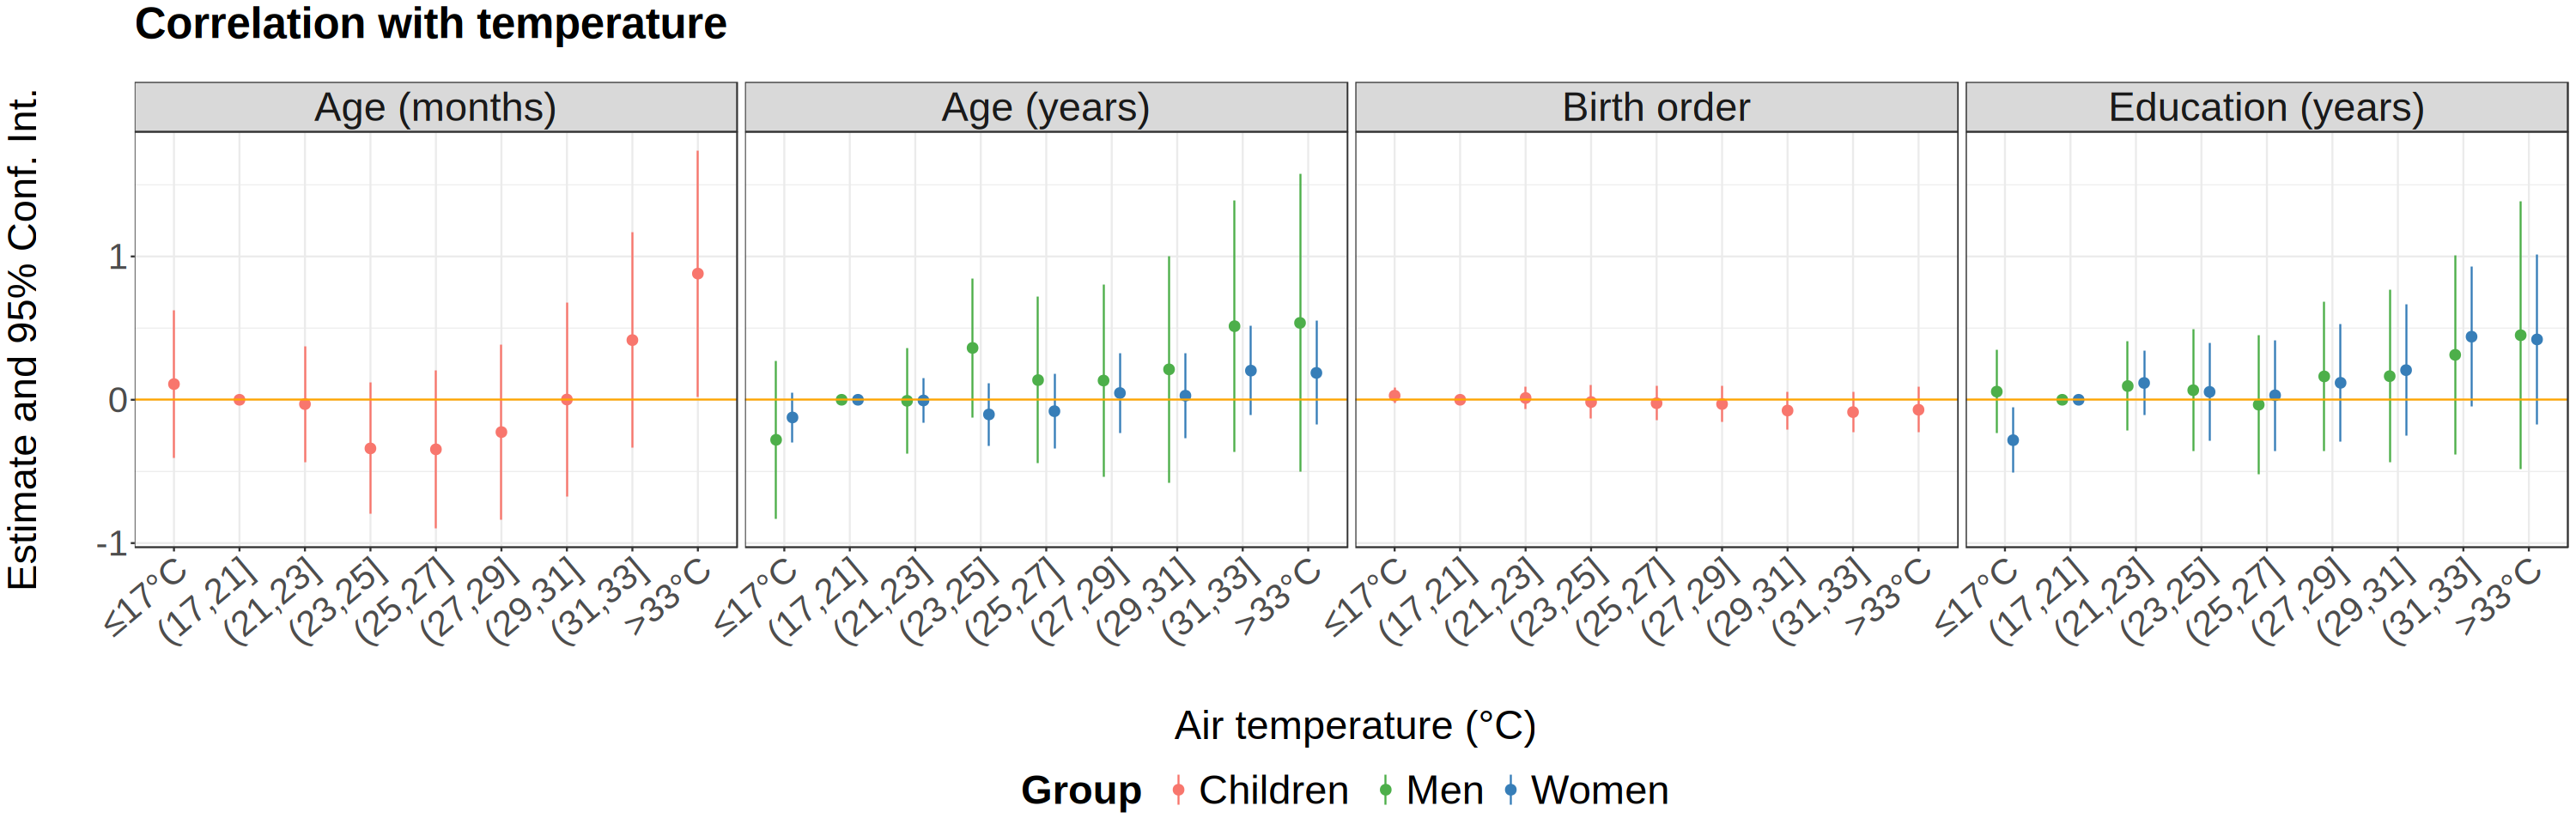

In [21]:
options(repr.plot.width=25, repr.plot.height=8, scipen=9999)

plot_estimates_years <- ggplot(all_coefs_years,aes(x=label, y=estimate, ymin=conf.low, ymax=conf.high, color=specifi)) +
                          geom_pointrange(position = position_dodge(width = 1/2)) +
                          geom_hline(yintercept = 0, col = "orange") +
                          labs(title="Correlation with temperature",subtitle="",
                               x="\n Air temperature (°C)", 
                               y="Estimate and 95% Conf. Int.\n", 
                               color="Group")+
                          scale_color_manual(values = c("Children"='#F8766D',"Women"='#377EB8',"Men"='#4DAF4A'),
                                             na.value="white")+
                          facet_wrap(~item, nrow=1)+
                          theme_bw() +
                          theme(plot.title = element_text(size = 30, face="bold"),
                                plot.subtitle = element_text(size = 15, face="bold"),
                                legend.position="bottom",
                                legend.title = element_text(size = 28,face ="bold"),
                                legend.text = element_text(size = 28),
                                strip.text.x = element_text(size = 28),
                                axis.text.x = element_text(size = 25, angle=40, hjust=1),
                                axis.text.y = element_text(size = 25),
                                axis.title.x = element_text(size = 28, hjust = 0.5),
                                axis.title.y = element_text(size = 28, hjust = 0.5))
plot_estimates_years

In [22]:
ggsave("./3_output/img/robustness_contin_var.png", width=25, height=8, plot_estimates_years)